In [1]:
import sys
import os

# Add parent directory of the notebook to sys.path
sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import pickle as pkl
from utils import *
from utils_plot import *
from tqdm import tqdm
import os
from utils_simple_access import *
import pandas as pd
import glob
import matplotlib.pyplot as plt
from torch import nn
import seaborn as sns
from copy import deepcopy
from utils_plot import *
from run_sim import Config, run_sim, run_sim_wrapper, create_data
from joblib import Parallel, delayed
import shutil
from matplotlib.gridspec import GridSpec

# Run scan_L_A.py to generate the results for Fig2.ipynb


In [3]:
C = Config()


C.print_progress = True
C.G = 1
C.linear_net = True
C.learning_rate = 0.001
C.length_corridors = [30]*2
C.hidden_size = len(C.length_corridors) * (C.length_corridors[0] * 3 - 1)*2
C.split_actions = True
C.num_epochs = 10000
C.algo_name = 'Adam'
C.loss_fn = nn.CrossEntropyLoss()
C.L = 10


var_name = 'max_move'
var_values = [1, C.length_corridors[0]//2]


In [4]:
# Ensure the results directory exists
results_dir = f'fig4_data'
if os.path.exists(results_dir):
    shutil.rmtree(results_dir)
os.makedirs(results_dir, exist_ok=True)

def run_and_save(var_value):
    C_local = deepcopy(C)
    setattr(C_local, var_name, var_value)
    # if var_value == 1:
    #     C_local.L = 1
    #     C.learning_rate = 0.1
    data_dict = run_sim_wrapper(C_local)
    out_path = os.path.join(results_dir, f'data_dict_{getattr(C_local, var_name)}.pkl')
    with open(out_path, 'wb') as f:
        pkl.dump(data_dict, f)
    return out_path

# Run in parallel
paths = Parallel(n_jobs=-1)(
    delayed(run_and_save)(var_value) for var_value in var_values
)
# Load all results into data_dict_l
data_dict_l = []
for path in paths:
    with open(path, 'rb') as f:
        data_dict_l.append(pkl.load(f))

for data_dict in data_dict_l:
    print(f'{var_name}: {getattr(data_dict["C"], var_name)} --- X shape: {data_dict["X"].shape} --- Number of hidden: {data_dict["C"].hidden_size}')

max_move: 1 --- X shape: torch.Size([176, 66]) --- Number of hidden: 356
max_move: 15 --- X shape: torch.Size([1380, 122]) --- Number of hidden: 356


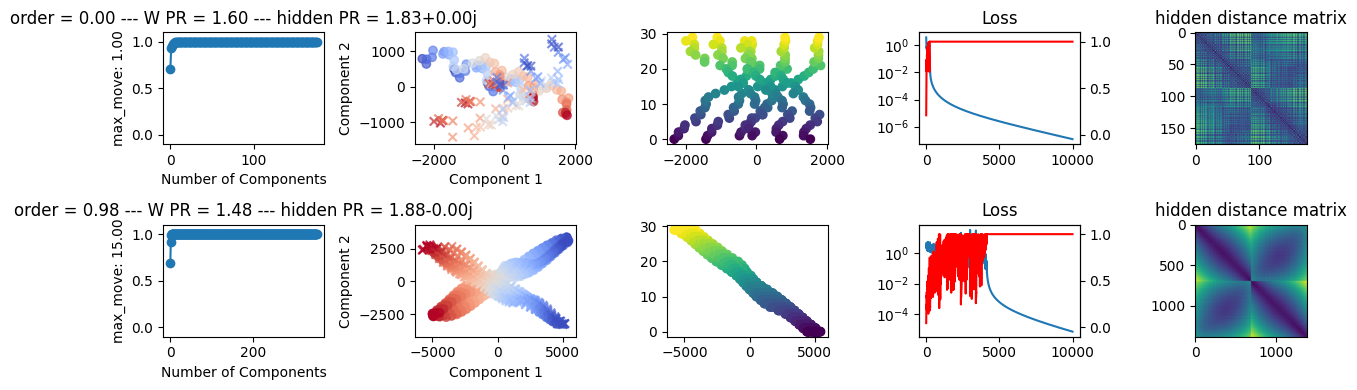

In [5]:
fig, axs = plt.subplots(len(data_dict_l), 5, figsize=(25/2, len(data_dict_l)*4/2))
for data_dict, axs_current in zip(data_dict_l, axs):
    plot_pca(data_dict, axs=axs_current)
    axs_current[0].set_ylabel(f'{var_name}: {getattr(data_dict["C"], var_name):.2f}')

In [6]:
# Set global matplotlib formatting for ICLR paper compatibility
# Set global font to Times New Roman

import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 18,
    'axes.labelsize': 18,
    'axes.titlesize': 20,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 22,
    'axes.linewidth': 1.2,
    'lines.linewidth': 2.0,
    'lines.markersize': 8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    'legend.frameon': False,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'figure.figsize': (6, 4),
    'pdf.fonttype': 42,  # TrueType fonts for compatibility
    'ps.fonttype': 42,
    'text.usetex': False,  # Set to True if you want LaTeX rendering and have it installed
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif', 'serif'],
})

import seaborn as sns
sns.set_context("paper")
sns.set_style("whitegrid")


In [7]:


def plot_pca_subplot(ax, data_dict, title, cb=False, plot_var=None):
    if plot_var is not None:
        h = plot_var
    else:
        h = data_dict['hidden_states'][-1].cpu().numpy()
    loc_y = data_dict['loc_y']
    action_taken = data_dict['action_taken']
    corridor = data_dict['corridor']
    cond = abs(action_taken) <= 1
    # If loc_y is 2D, color by the first dimension
    color = loc_y[:, 0] if loc_y.ndim > 1 else loc_y
    color = color[cond]
    h = h[cond]
    corridor = corridor[cond]
    # PCA to 2D
    from sklearn.decomposition import PCA
    h_pca = PCA(n_components=2).fit_transform(h)
    
    # Get corridor information and markers
    markers = ['o', 'v', '*', 'v', '^', 'p', 'h', '8', 'X', 'd']
    
    # Plot each corridor with different markers
    for cor, marker in zip(np.unique(corridor), markers):
        mask = corridor == cor
        sc = ax.scatter(
            h_pca[mask, 0], h_pca[mask, 1], c=color[mask], cmap='viridis',
            s=80, alpha=0.9, edgecolor='none', marker=marker
        )
    ax.set_title(title, fontsize=20, pad=10)
    ax.axis('equal')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(False)
    if cb:
        cbar = plt.colorbar(sc, ax=ax, pad=0.01, fraction=0.05)
        cbar.ax.set_yticklabels([])  # Remove colorbar ticks
        cbar.set_label('location', fontsize=16)

(60, 60) (60, 66) (60,)
(60, 60) (60, 122) (60,)


C:\Users\avivra\AppData\Local\Temp\ipykernel_22144\308577333.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


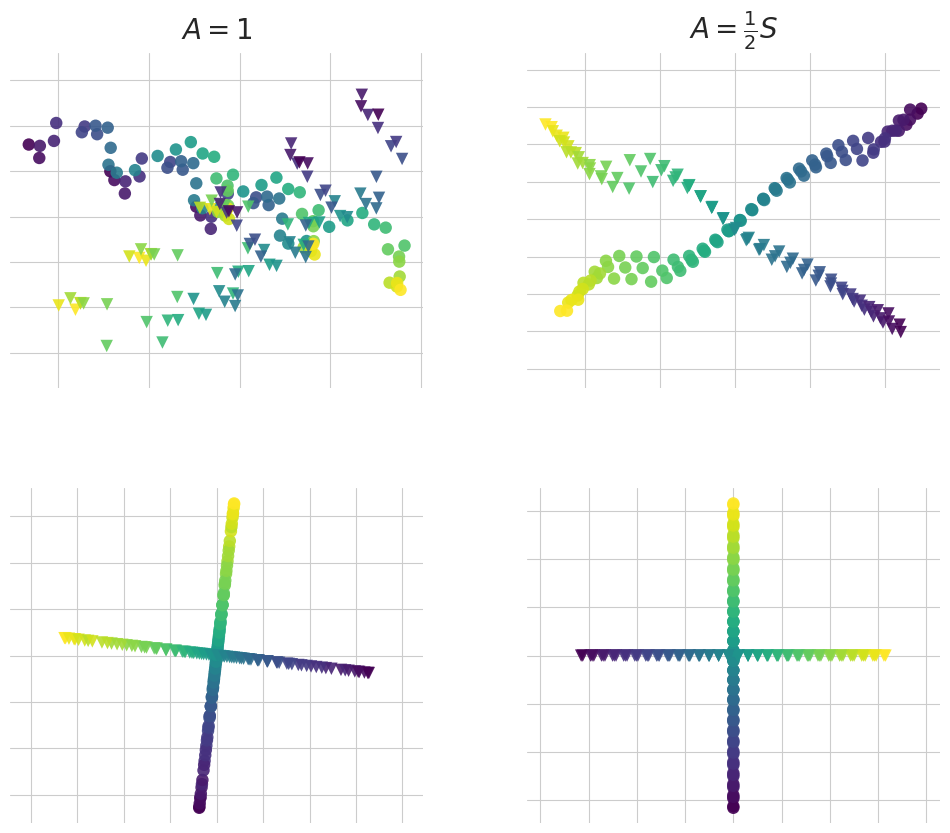

In [8]:

fig = plt.figure(figsize=(12, 10))
gs = GridSpec(2, 2, height_ratios=[1, 1], hspace=0.3, wspace=0.25)

for i in range(2):
    data_dict = data_dict_l[i]
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    corridor = data_dict['corridor']

    ax = fig.add_subplot(gs[0, i])
    plot_pca_subplot(ax, data_dict, [r'$A=1$', r'$A=\frac{1}{2}S$'][i])

    Sigma11 = np.array(X.T@X, dtype=np.float64)
    Sigma31 = np.array(y.T@X, dtype=np.float64)
    # W = get_effective_W_from_model_dict(data_dict['final_weights']).cpu().numpy()
    # W /= np.linalg.norm(W, axis=0)
    U, S, V = np.linalg.svd(Sigma31@np.linalg.pinv(Sigma11), full_matrices=False)
    print(U.shape, V.shape, S.shape)
    ax = fig.add_subplot(gs[1, i])
    plot_pca_subplot(ax, data_dict, '', plot_var=X@V[:2].T@np.diag(S[:2]))

    # rank = 1
    # ax.plot(V[:rank].T, label='data')
    # U, S, V = np.linalg.svd(W, full_matrices=False)
    # ax.plot(U[:, :rank], label='model')
    # ax.set_title('First singular vector')
ax.legend()
os.makedirs('./final_results/figures', exist_ok=True)
fig.savefig('./figures/fig4.png', dpi=300)


X shape: (176, 66) --- U shape: (60, 60) --- V shape: (60, 66)
X shape: (1380, 122) --- U shape: (60, 60) --- V shape: (60, 122)


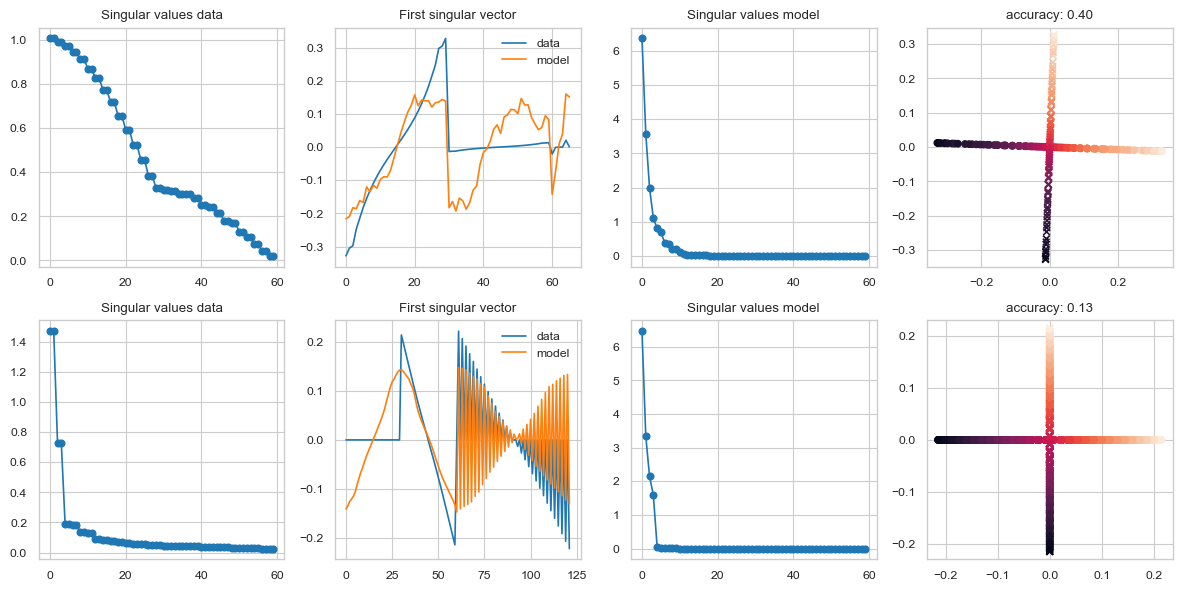

In [9]:
fig, axs_l = plt.subplots(2, 4, figsize=(4*3, 6))

for data_dict, axs in zip(data_dict_l, axs_l):
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    corridor = data_dict['corridor']
    Sigma11 = np.array(X.T@X, dtype=np.float64)
    Sigma31 = np.array(y.T@X, dtype=np.float64)
    W = get_effective_W_from_model_dict(data_dict['final_weights']).cpu().numpy()
    W /= np.linalg.norm(W, axis=0)
    U, S, V = np.linalg.svd(Sigma31@np.linalg.pinv(Sigma11), full_matrices=False)
    print(f'X shape: {X.shape} --- U shape: {U.shape} --- V shape: {V.shape}')
    rank = 1
    axs[0].plot(S, marker='o')
    axs[0].set_title('Singular values data')
    axs[1].plot(V[:rank].T, label='data')

    U, S, V = np.linalg.svd(W, full_matrices=False)
    axs[1].plot(U[:, :rank], label='model')
    axs[1].legend()
    axs[1].set_title('First singular vector')
    axs[2].plot(S, marker='o')
    axs[2].set_title('Singular values model')
    plt.tight_layout()
    

    W_corr = Sigma31@np.linalg.pinv(Sigma11)
    U, S, V = np.linalg.svd(W_corr.T, full_matrices=False)
    for cor, marker in zip(np.unique(corridor), markers):
        axs[-1].scatter(X[corridor==cor]@U[:, 0], X[corridor==cor]@U[:, 1], c=y[corridor==cor].argmax(1), marker=marker)
    axs[-1].set_title(f'accuracy: {calc_accuracy_from_W(W_corr.T, X, y):.2f}')
    axs[-1].axis('equal')
os.makedirs('./final_results/figures', exist_ok=True)
fig.savefig('./final_results/figures/fig4.png', dpi=300)
plt.show()
